# Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import duckdb
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rcParams
rcParams["text.usetex"] = True

import osbad.config as bconf

# Import dataset

## Available cell_index

In [2]:
# Path to database directory
# "tohoku_benchmark_dataset.db" inside the database folder
DB_DIR = bconf.DB_DIR

db_filepath = DB_DIR.joinpath("tohoku_benchmark_dataset.db")

# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all training dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_tohoku_dataset").fetchdf()

# Drop the additional index column
df_duckdb = df_duckdb.drop(
    columns="__index_level_0__",
    errors="ignore")

unique_cell_index_train = df_duckdb["cell_index"].unique()
print(unique_cell_index_train)

['cell_num_1' 'cell_num_2' 'cell_num_3' 'cell_num_4' 'cell_num_5'
 'cell_num_6' 'cell_num_7' 'cell_num_8' 'cell_num_9' 'cell_num_10']


## Define metrics filepath

In [3]:
TRAIN_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "01_train_dataset",
    "eval_metrics_hp_single_cell_tohoku.csv")

VALIDATE_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "02_validation_dataset",
    "eval_metrics_tohoku_train_multiple_cells.csv")

TEST_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "03_test_dataset",
    "eval_metrics_tohoku_test_multiple_cells.csv")


# 01: Train on a single cell

* The models are trained and evaluated on the dataset from a single cell
* While all models have perfect accuracy, precision, recall, F1-score and MCC score from the training and evaluation based on a single cell, it also implies that the models could be overfitted.
* Therefore, it is important to consider how the models perform across the dataset from multiple cells.

## Plot evaluation metrics for a single cell

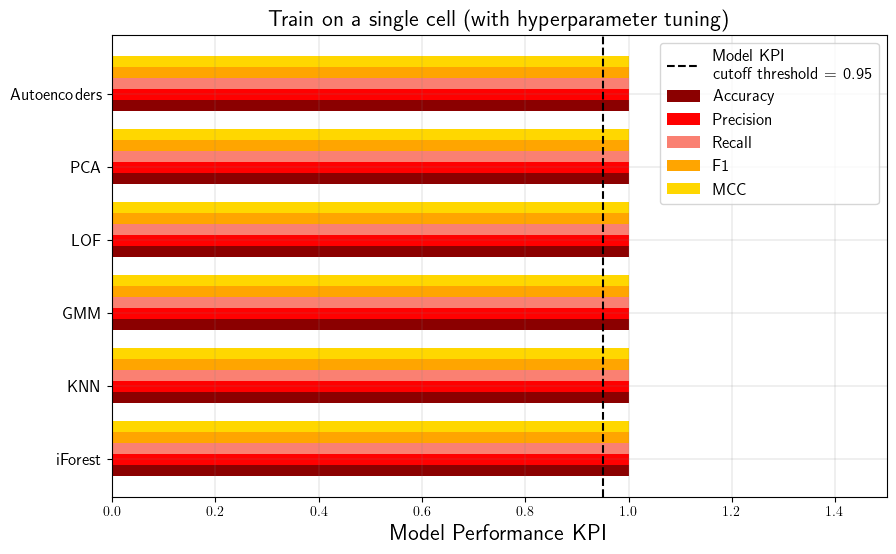

In [4]:
df_eval_metrics_train = pd.read_csv(TRAIN_DATASET_METRICS_PATH)

list_acc = df_eval_metrics_train["accuracy"].to_list()
list_precision = df_eval_metrics_train["precision"].to_list()
list_recall = df_eval_metrics_train["recall"].to_list()
list_f1 = df_eval_metrics_train["f1_score"].to_list()
list_mcc = df_eval_metrics_train["mcc_score"].to_list()

fig, ax = plt.subplots(figsize=(10,6))

bar_width = 0.15

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Train on a single cell (with hyperparameter tuning)",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_hp_single_cell.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 02: Validation across multiple cells

For the **hyperparameter tuning using the transfer learning method**:

* In the validation stage, the hyperparameter tuning is performed across 23 different cell experimental dataset.
* The best trial parameters are recorded for each model across all cells.
* The hyperparameters are subsequently averaged and transfer to the test dataset (another 23 cells).
* The corresponding model metrics are also recorded and then averaged to evaluate how each model performs across 23 different cell dataset during the validation stage.

## Drop duplicates in the training dataset

* Some metrics have been evaluated multiple times for the same ``ml_model`` and ``cell_index``
* ``df_eval_metrics_validate`` ensures that the combined ``ml_model`` and ``cell_index`` are unique

In [5]:
df_eval_metrics_validate = pd.read_csv(VALIDATE_DATASET_METRICS_PATH)

df_eval_metrics_validate = df_eval_metrics_validate.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")

## Calculate average metrics

* Calculate the mean of ``accuracy``, ``precision``, ``recall``, ``f1_score`` and ``mcc_score`` across all evaluated cells in the training dataset.

In [6]:
eval_metrics_all_models_list = []

avg_accuracy_dict = {}
avg_precision_dict = {}
avg_recall_dict = {}
avg_f1_score_dict = {}
avg_mcc_dict = {}

for selected_model in df_eval_metrics_validate["ml_model"].unique():
    print(f"Evaluating {selected_model}")

    df_selected_model = (
        df_eval_metrics_validate[df_eval_metrics_validate["ml_model"] 
        == selected_model])

    avg_accuracy = np.mean(df_selected_model["accuracy"])
    print(f"Average accuracy: {avg_accuracy}")
    avg_accuracy_dict.update({selected_model: avg_accuracy})
    
    avg_precision = np.mean(df_selected_model["precision"])
    print(f"Average precision: {avg_precision}")
    avg_precision_dict.update({selected_model: avg_precision})
    
    avg_recall = np.mean(df_selected_model["recall"])
    print(f"Average recall: {avg_recall}")
    avg_recall_dict.update({selected_model: avg_recall})
    
    avg_f1_score = np.mean(df_selected_model["f1_score"])
    print(f"Average F1 score: {avg_f1_score}")
    avg_f1_score_dict.update({selected_model: avg_f1_score})
    
    avg_mcc_score = np.mean(df_selected_model["mcc_score"])
    print(f"Average MCC score: {avg_mcc_score}")
    avg_mcc_dict.update({selected_model: avg_mcc_score})
    
    print("-"*70)

    eval_dict = {
        "ml_model": selected_model,
        "avg_accuracy": [avg_accuracy],
        "avg_precision": [avg_precision],
        "avg_recall": [avg_recall],
        "avg_f1_score": [avg_f1_score],
        "avg_mcc_score": [avg_mcc_score]
    }
    
    df_eval_metrics_per_model = pd.DataFrame.from_dict(eval_dict)
    eval_metrics_all_models_list.append(df_eval_metrics_per_model)

Evaluating iforest
Average accuracy: 1.0
Average precision: 1.0
Average recall: 1.0
Average F1 score: 1.0
Average MCC score: 1.0
----------------------------------------------------------------------
Evaluating knn
Average accuracy: 0.999
Average precision: 1.0
Average recall: 0.8333333333333333
Average F1 score: 0.875
Average MCC score: 0.894048023239932
----------------------------------------------------------------------
Evaluating gmm
Average accuracy: 0.997442367601246
Average precision: 1.0
Average recall: 0.6666666666666666
Average F1 score: 0.75
Average MCC score: 0.7879338286551988
----------------------------------------------------------------------
Evaluating lof
Average accuracy: 0.999
Average precision: 1.0
Average recall: 0.8333333333333333
Average F1 score: 0.875
Average MCC score: 0.894048023239932
----------------------------------------------------------------------
Evaluating pca
Average accuracy: 0.9984423676012462
Average precision: 1.0
Average recall: 0.83333333

In [7]:
df_compare_metrics = pd.concat(
    eval_metrics_all_models_list).reset_index(drop=True)

df_compare_metrics

,ml_model,avg_accuracy,avg_precision,avg_recall,avg_f1_score,avg_mcc_score
0,iforest,1.000000,1.0,1.000000,1.000,1.000000
1,knn,0.999000,1.0,0.833333,0.875,0.894048
2,gmm,0.997442,1.0,0.666667,0.750,0.787934
3,lof,0.999000,1.0,0.833333,0.875,0.894048
4,pca,0.998442,1.0,0.833333,0.875,0.893886
5,autoencoder,0.998442,1.0,0.833333,0.875,0.893886


## Plot evaluation metrics for all cells

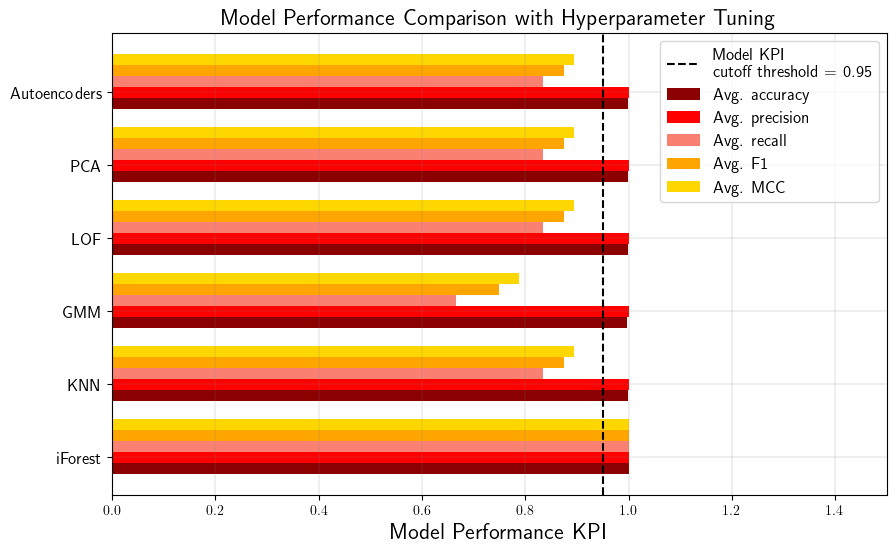

In [8]:
list_acc = df_compare_metrics["avg_accuracy"].to_list()
list_precision = df_compare_metrics["avg_precision"].to_list()
list_recall = df_compare_metrics["avg_recall"].to_list()
list_f1 = df_compare_metrics["avg_f1_score"].to_list()
list_mcc = df_compare_metrics["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Model Performance Comparison with Hyperparameter Tuning",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_with_hp_multiple_cells.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 03: Test across multiple cells

* No more hyperparameter tuning is performed during the test phase.
* The models are simply tested on the remaining 23 cells to evaluate how each model with the frozen hyperparameters generalize to new dataset.

## Drop duplicates in the test dataset

In [10]:
df_eval_metrics_test = pd.read_csv(TEST_DATASET_METRICS_PATH)

df_eval_metrics_test = df_eval_metrics_test.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")
df_eval_metrics_test

,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,iforest,cell_num_7,1.000000,1.000000,1.00,1.000000,1.000000
1,iforest,cell_num_8,1.000000,1.000000,1.00,1.000000,1.000000
2,iforest,cell_num_9,1.000000,1.000000,1.00,1.000000,1.000000
3,iforest,cell_num_10,0.991667,1.000000,0.80,0.888889,0.890564
4,knn,cell_num_7,1.000000,1.000000,1.00,1.000000,1.000000
5,knn,cell_num_8,0.994949,1.000000,0.50,0.666667,0.705310
6,knn,cell_num_9,1.000000,1.000000,1.00,1.000000,1.000000
7,knn,cell_num_10,1.000000,1.000000,1.00,1.000000,1.000000
8,gmm,cell_num_7,0.996656,1.000000,0.50,0.666667,0.705919
9,gmm,cell_num_8,0.994949,1.000000,0.50,0.666667,0.705310


In [11]:
unique_model_namelist = (
    df_eval_metrics_test["ml_model"].unique())
print(f"Unique model name list: {unique_model_namelist}")

Unique model name list: ['iforest' 'knn' 'gmm' 'lof' 'pca' 'autoencoder']


## Calculate average metrics

In [12]:
test_eval_metrics_all_models_list = []

avg_accuracy_testdict = {}
avg_precision_testdict = {}
avg_recall_testdict = {}
avg_f1_score_testdict = {}
avg_mcc_testdict = {}

for selected_model in df_eval_metrics_test["ml_model"].unique():
    print(f"Evaluating {selected_model}")

    df_selected_model = (
        df_eval_metrics_test[df_eval_metrics_test["ml_model"] 
        == selected_model])

    avg_accuracy = np.mean(df_selected_model["accuracy"])
    print(f"Average accuracy: {avg_accuracy}")
    avg_accuracy_testdict.update({selected_model: avg_accuracy})
    
    avg_precision = np.mean(df_selected_model["precision"])
    print(f"Average precision: {avg_precision}")
    avg_precision_testdict.update({selected_model: avg_precision})
    
    avg_recall = np.mean(df_selected_model["recall"])
    print(f"Average recall: {avg_recall}")
    avg_recall_testdict.update({selected_model: avg_recall})
    
    avg_f1_score = np.mean(df_selected_model["f1_score"])
    print(f"Average F1 score: {avg_f1_score}")
    avg_f1_score_testdict.update({selected_model: avg_f1_score})
    
    avg_mcc_score = np.mean(df_selected_model["mcc_score"])
    print(f"Average MCC score: {avg_mcc_score}")
    avg_mcc_testdict.update({selected_model: avg_mcc_score})
    
    print("-"*70)

    eval_testdict = {
        "ml_model": selected_model,
        "avg_accuracy": [avg_accuracy],
        "avg_precision": [avg_precision],
        "avg_recall": [avg_recall],
        "avg_f1_score": [avg_f1_score],
        "avg_mcc_score": [avg_mcc_score]
    }
    
    df_eval_metrics_per_model = pd.DataFrame.from_dict(eval_testdict)
    test_eval_metrics_all_models_list.append(df_eval_metrics_per_model)

df_compare_metrics_test = pd.concat(
    test_eval_metrics_all_models_list).reset_index(drop=True)

df_compare_metrics_test

Evaluating iforest
Average accuracy: 0.9979166666666667
Average precision: 1.0
Average recall: 0.95
Average F1 score: 0.9722222222222222
Average MCC score: 0.9726408891404303
----------------------------------------------------------------------
Evaluating knn
Average accuracy: 0.9987373737373737
Average precision: 1.0
Average recall: 0.875
Average F1 score: 0.9166666666666666
Average MCC score: 0.9263274526509574
----------------------------------------------------------------------
Evaluating gmm
Average accuracy: 0.9908828756427533
Average precision: 1.0
Average recall: 0.4625
Average F1 score: 0.6208333333333333
Average MCC score: 0.6690764961715696
----------------------------------------------------------------------
Evaluating lof
Average accuracy: 0.9987373737373737
Average precision: 1.0
Average recall: 0.875
Average F1 score: 0.9166666666666666
Average MCC score: 0.9263274526509574
----------------------------------------------------------------------
Evaluating pca
Average a

,ml_model,avg_accuracy,avg_precision,avg_recall,avg_f1_score,avg_mcc_score
0,iforest,0.997917,1.000000,0.9500,0.972222,0.972641
1,knn,0.998737,1.000000,0.8750,0.916667,0.926327
2,gmm,0.990883,1.000000,0.4625,0.620833,0.669076
3,lof,0.998737,1.000000,0.8750,0.916667,0.926327
4,pca,0.964674,0.804878,0.9125,0.802521,0.817084
5,autoencoder,0.999049,1.000000,0.9375,0.964286,0.966090


## Plot evaluation metrics

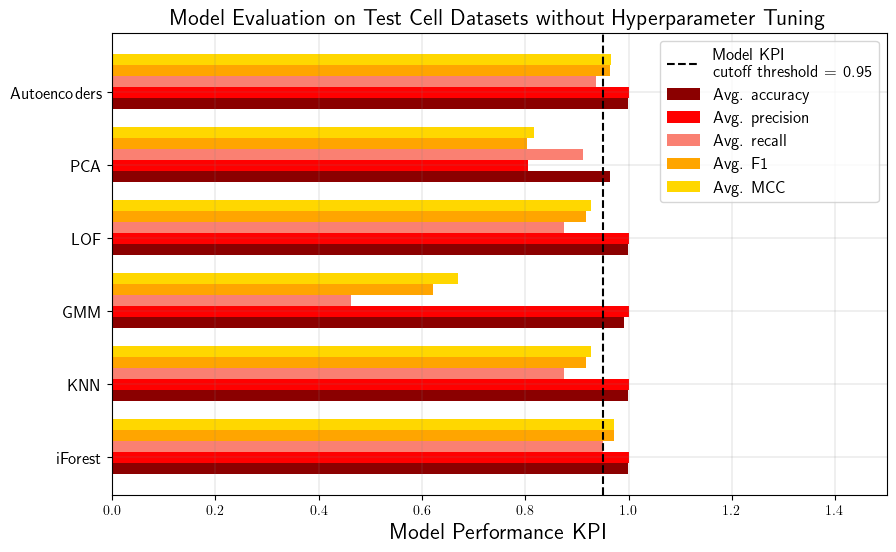

In [13]:
list_acc = df_compare_metrics_test["avg_accuracy"].to_list()
list_precision = df_compare_metrics_test["avg_precision"].to_list()
list_recall = df_compare_metrics_test["avg_recall"].to_list()
list_f1 = df_compare_metrics_test["avg_f1_score"].to_list()
list_mcc = df_compare_metrics_test["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Model Evaluation on Test Cell Datasets without Hyperparameter Tuning",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_test.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()